In [62]:
import pandas as pd

In [63]:
def extract_data_from_log(file_path: str):
    """
    Function to extract the `per_barcode_raw_read_counts` data
    from the stacks process_radtags log
    """

    with open(file_path, 'r') as f:
        index = 0
        data = []
        for line in f:
            line = line.strip()

            if line == "BEGIN per_barcode_raw_read_counts":
                index += 1
            elif line == "END per_barcode_raw_read_counts":
                break
            elif index == 1:
                colnames = line.split('\t')
                index += 1
            elif index > 1:
                data.append(line.split('\t'))

        out = pd.DataFrame(data, columns=colnames)
    return out


In [64]:
plate1 = extract_data_from_log("../../data/raw/process_radtags_plate1.log")
plate2 = extract_data_from_log("../../data/raw/process_radtags_plate2.log")
plate3 = extract_data_from_log("../../data/raw/process_radtags_plate3.log")

In [65]:
df = pd.concat([plate1, plate2, plate3])
df = df[df['Filename'] != 'FGXCONTROL']

In [66]:
df['Pct Total Reads'].value_counts()

Pct Total Reads
0.5%    42
0.6%    42
0.7%    29
0.4%    23
0.9%    18
0.8%    17
1.0%    17
0.3%     7
1.1%     6
1.2%     6
1.5%     4
0.1%     3
0.0%     3
1.3%     3
0.2%     1
1.6%     1
Name: count, dtype: int64

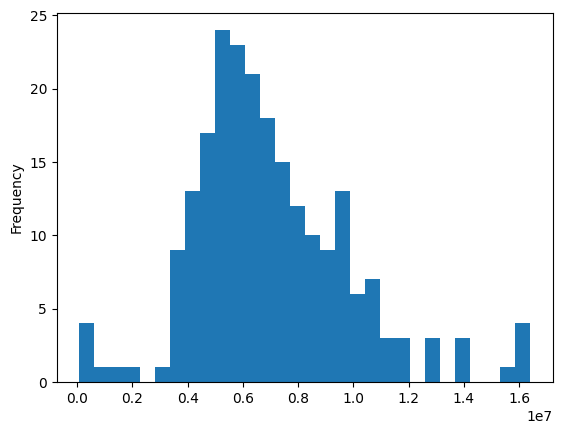

In [67]:
df['Retained Reads'] = df['Retained Reads'].astype(int)
df['Retained Reads'].plot.hist(bins=30);

In [68]:
df['Retained Reads'].describe()

count    2.220000e+02
mean     7.011607e+06
std      2.860426e+06
min      8.025200e+04
25%      5.177988e+06
50%      6.518902e+06
75%      8.616277e+06
max      1.641055e+07
Name: Retained Reads, dtype: float64

In [69]:
df[df['Retained Reads'] <= 1000000]

,Barcode,Filename,Total,RAD Cutsite Not Found,Low Quality,Poly-G Runs,Retained Reads,Pct Retained,Properly Paired,Pct Properly Paired,Pct Total Reads
68,CGGTCGTTAC,2001_Mona_LTC4,961992,14094,1183,186570,760145,79.0%,300780,62.5%,0.1%
3,TCGCCGCAAT,2022_Tooele_Army_LTC_11,89332,8626,243,211,80252,89.8%,35706,79.9%,0.0%
4,TCAGTTCCGG,2022_Tooele_Army_LTC_12,129860,5714,271,291,123584,95.2%,58753,90.5%,0.0%
5,CGGAAGTGAG,2022_Tooele_Army_LTC_13,565584,11591,1023,1340,551630,97.5%,269078,95.2%,0.1%
6,GTTGCTAGAC,2022_Tooele_Army_LTC_14,94894,2449,143,254,92048,97.0%,44667,94.1%,0.0%


In [70]:
df[df['Filename'].str.contains('Mona')]

,Barcode,Filename,Total,RAD Cutsite Not Found,Low Quality,Poly-G Runs,Retained Reads,Pct Retained,Properly Paired,Pct Properly Paired,Pct Total Reads
65,GCCGGTGATT,2001_Mona_LTC1,6828904,250197,10267,1304535,5263905,77.1%,2033623,59.6%,0.5%
66,AGACGAATAG,2001_Mona_LTC2,6270534,215341,9245,1199613,4846335,77.3%,1877155,59.9%,0.5%
67,GGTCATTGTA,2001_Mona_LTC3,4703850,154736,7176,902851,3639087,77.4%,1410710,60.0%,0.3%
68,CGGTCGTTAC,2001_Mona_LTC4,961992,14094,1183,186570,760145,79.0%,300780,62.5%,0.1%
69,GACGGACAGG,2001_Mona_LTC5,9083002,481036,12474,1710849,6878643,75.7%,2609557,57.5%,0.7%
70,ATTGCCACCG,2001_Mona_LTC6,4863832,267969,6781,914491,3674591,75.5%,1391332,57.2%,0.3%
71,CAGAACCAGC,2001_Mona_LTC7,6208046,521809,8900,1137497,4539840,73.1%,1659000,53.4%,0.4%
72,GCTGTGCAGA,2001_Mona_LTC8,5077002,130031,7163,980995,3958813,78.0%,1546249,60.9%,0.4%
73,AAGACCAATC,2001_Mona_LTC9,6583586,472827,9397,1219780,4881582,74.1%,1812110,55.0%,0.5%
74,CGCGCGGCTG,2001_Mona_LTC10,4542008,175501,7008,867223,3492276,76.9%,1345875,59.3%,0.3%


In [71]:
import re
df['population'] = df['Filename'].apply(lambda x: re.sub('[0-9]+_(.+)_LTC.+', '\\1', x))

In [72]:
df_fil = df[df['Retained Reads'] > 1000000].reset_index(drop=True)
df_fil['population'].value_counts()

population
Bishop           15
Red_Knolls       15
Clear_Lake       15
Willow_Pond      15
Gandy            15
Leland_Harris    15
Big_Springs      15
Copilot          15
Cluster          15
Rosebud_Top_P    14
Mona             14
Lower_Rocky      14
Jail_Pond        14
Tooele_Army      10
Keg_Springs       8
Mills_Valley      8
Name: count, dtype: int64

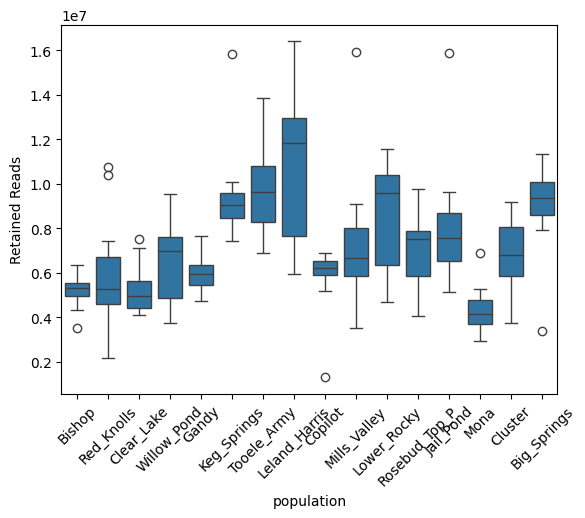

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

ax = sns.boxplot(data=df_fil, x='population', y='Retained Reads')

ax.tick_params(axis='x', labelrotation=45)

plt.show()

In [74]:
df_fil['z_score_retained'] = df_fil['Retained Reads'].apply(lambda x: (x - df_fil['Retained Reads'].mean())/df_fil['Retained Reads'].std())

In [79]:
# Use the z score of retained reads to get a list of individuals that are near the mean 
# Threshold of 0.75 ensures at least 2 individuals are retained from each population
df_fil[(df_fil['z_score_retained'] >= -0.75) & (df_fil['z_score_retained'] <= 0.75)]['population'].value_counts()

population
Copilot          14
Gandy            13
Cluster          13
Bishop           10
Rosebud_Top_P    10
Jail_Pond        10
Willow_Pond       9
Red_Knolls        7
Mills_Valley      6
Clear_Lake        6
Leland_Harris     6
Keg_Springs       5
Tooele_Army       5
Big_Springs       5
Lower_Rocky       4
Mona              2
Name: count, dtype: int64

In [81]:
df_opt = (
    df_fil[(df_fil['z_score_retained'] >= -0.75) & (df_fil['z_score_retained'] <= 0.75)]
    .groupby('population')
    .sample(n=2, replace=False, random_state=42)
    .reset_index(drop=True)
)

In [82]:
df_opt

,Barcode,Filename,Total,RAD Cutsite Not Found,Low Quality,Poly-G Runs,Retained Reads,Pct Retained,Properly Paired,Pct Properly Paired,Pct Total Reads,population,z_score_retained
0,TTGATGGTGC,2022_Big_Springs_LTC_6,8824612,9773,16359,23669,8774811,99.4%,4365920,98.9%,0.9%,Big_Springs,0.595143
1,TCACTGAGAA,2022_Big_Springs_LTC_15,8524310,41794,16245,22079,8444192,99.1%,4185217,98.2%,0.9%,Big_Springs,0.472857
2,TCAGTTCCGG,2022_Bishop_LTC5,6964338,69880,6133,1602217,5286108,75.9%,1999150,57.4%,0.5%,Bishop,-0.695228
3,TTGCGCAAGC,2022_Bishop_LTC15,7099276,91420,6064,1628541,5373251,75.7%,2030695,57.2%,0.5%,Bishop,-0.662996
4,ACATCAATAT,2022_Clear_Lake_LTC2,9955048,126487,8303,2292283,7527975,75.6%,2841676,57.1%,0.7%,Clear_Lake,0.133974
5,TTATCCGTAG,2022_Clear_Lake_LTC8,7197736,68673,5827,1653276,5469960,76.0%,2072039,57.6%,0.5%,Clear_Lake,-0.627226
6,CTAACAGTAT,2022_Cluster_LTC_15,8294900,77187,15081,21717,8180915,98.6%,4036932,97.3%,0.8%,Cluster,0.375478
7,TGTCCTAGGA,2022_Cluster_LTC_9,6151230,19673,10561,16436,6104560,99.2%,3031387,98.6%,0.6%,Cluster,-0.392506
8,GCTCAGCCAG,2022_Copilot_LTC2,8494676,104886,12670,1653563,6723557,79.2%,2665658,62.8%,0.6%,Copilot,-0.163557
9,CTTCGACATA,2022_Copilot_LTC14,7369946,105955,11552,1436241,5816198,78.9%,2298600,62.4%,0.5%,Copilot,-0.499163


In [83]:
df_opt['pop'] = 'opt'

In [91]:
df_fil[['Filename', 'population']].to_csv('../popmap.tsv', sep='\t', index=False, header=False)
df_opt[['Filename', 'pop']].to_csv('../opt_popmap.tsv', sep='\t', index=False, header=False)